This notebook contains some basic code implementing in numpy the expressions for the HES T -> T T amplitude in the high-energy fixed-angle limit, and using it to compute and plot the amplitude.

The accurate computation of the curves of the zeros of the derivative at large N requires high precision in the coefficients (~ N significant digits) and cannot be computed with float64 precision. For our purposes, we implemented them in Mathematica where polynomial equations can be solved to arbitrary precision natively, but it should be possible to expand this code and use packages designed to handle high precision computation. If optimized, it should run faster than the Mathematica notebook.

In [1]:
# Imports and auxiliary definitions

# Math and science imports
import scipy as sp
import numpy as np
import math

import random

import matplotlib.pyplot as plt


# Default font sizes for plots
plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

# Default path to save plots
from datetime import datetime
figurepath = 'c:\\users\\Dorin\\Dropbox\\Mathematica\\String Chaos\\Figures\\Temp\\'
def fname():
    return figurepath + 'HTTT-' + datetime.strftime(datetime.now(),'%y-%m-%d-%H-%M-%S') + '.png'

# MATLAB-style tic and toc functions
import time

_timer_start = None

def tic():
    global _timer_start
    _timer_start = time.perf_counter()

def toc():
    elapsed = time.perf_counter() - _timer_start
    print(f"Elapsed time: {elapsed:.6f} seconds")

In [2]:
# Defining the amplitude

# Shorthand notation for important functions
hf = sp.special.hyp2f1
sqrt = math.sqrt

# Define the polynomials that enter the HT->TT amplitude
# Note that we use the definition in terms of the 2F1 hypergeometric function,
# related to the Jacobi polynomials by well known identities
def pn(n,x,y):
    return hf(1-n,1-n-n*sqrt(1-x**2)*y,2-2*n,2/(1+x))

def Pn(n,x,y):
    if n == 1:
        return sqrt(1-x**2)*sqrt(1-y**2)
    else:
        return sqrt(1-x**2)*sqrt(1-y**2) / (1+x) * hf(1-n,1-n-n*sqrt(1-x**2)*y,2-2*n,2/(1+x))

# Define the amplitude for a partition given by its gn
def amp(gn,x,y):
    res = 1
    for k in range(len(gn)):
        if gn[k] != 0:
            res = res * (Pn(k+1,x,y)**gn[k])
    return res

# Find g_n from representation of partition in terms of summands:
def findgn(prt):
    gn = np.zeros(max(prt),int)
    for k in range(max(prt)):
        gn[k] = prt.count(k+1)
    return gn

In [3]:
# Compute the amplitude for a given partition, on a given range of x and y

# range
xmin = -0.99
xmax = 0.99
ymin = -0.99
ymax = 0.99
# resolution
dx = 0.005
dy = dx
# meshgrid for plotting
x, y = np.meshgrid(np.arange(xmin,xmax,dx), np.arange(ymin,ymax,dy))

# Choose the function to be computed and vectorize it
# (in this application, we only use the amplitude)
f = np.vectorize(amp, excluded=[0])

In [4]:
# choose the partition (random partition not implemented here)
prt = [3]
prt = [7,4,3,2,2,1,1]

gn = findgn(prt)

JJ = sum(gn)
NN = sum(np.array(range(1,len(gn)+1))*gn)

# Compute the function for this choice of partition
tic()
z = f(gn,x,y)
toc()
print(f'N = {NN}, J = {JJ}')

Elapsed time: 9.570274 seconds
N = 20, J = 7


In [5]:
# Do numerical derivatives (better to write analytic expressions for the derivatives where available)
eps = 1e-8
xp, yp = np.meshgrid(np.arange(xmin,xmax,dx)+eps, np.arange(ymin,ymax,dy)+eps)
tic()
dxf = (f(gn,xp,y)-z)/eps
toc()
dyf = (f(gn,x,yp)-z)/eps
toc()

Elapsed time: 10.065762 seconds
Elapsed time: 21.417436 seconds


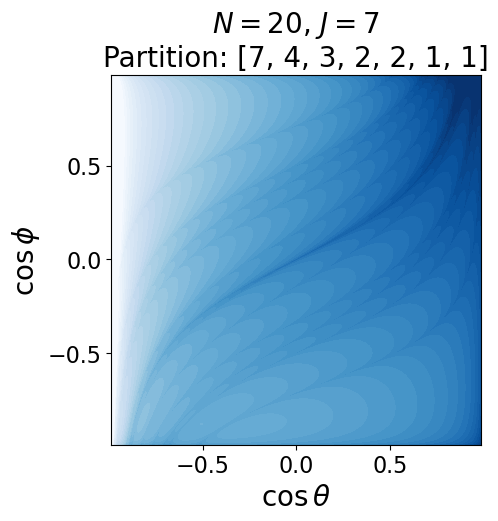

In [12]:
# Contour plot of log|D|

fig, ax = plt.subplots()

# Choose what to plot: in our case log|D|
# We normalize by dividing by N
zval = np.log(np.abs(z))/NN

# Manually set the min and max values to plot
zmin = -2
zmax = 2
zval = np.clip(zval,zmin,zmax)

# Adjust number of contours to improve contrast
n_contour = 48


plt.contourf(x,y,zval, levels=n_contour,cmap='Blues_r')
# plt.colorbar()
plt.xlabel("$\\cos\\theta$")
plt.ylabel("$\\cos\\phi$")
plt.xticks([-1,-0.5,0,0.5,1])
plt.yticks([-1,-0.5,0,0.5,1])
plt.axis('scaled')
# plt.title("$|\\log {\\cal D}|$\n$N=3$, $J=1$")
plt.title('$N = ' + str(NN) + '$, $J = ' + str(JJ) + '$\nPartition: ' + str(prt))
plt.savefig(fname(),dpi=200,bbox_inches='tight')

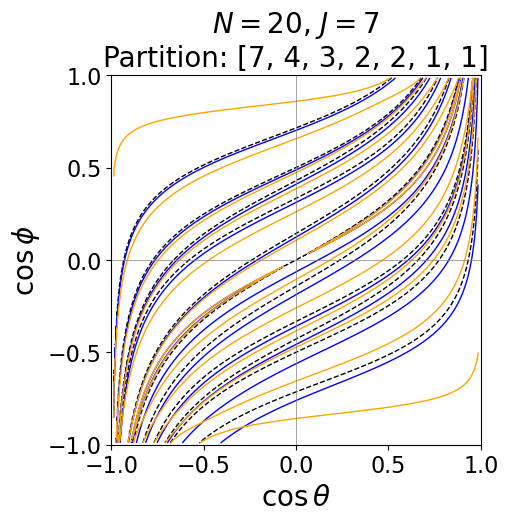

In [13]:
# Draw the curves where the zeros of the derivative are

fig, ax = plt.subplots()
ax.contour(x,y,z,levels=[0],linestyles='dashed',colors='black',linewidths=1)
ax.contour(x,y,dxf,levels=[0],colors='blue',linewidths=1)
ax.contour(x,y,dyf,levels=[0],colors='orange',linewidths=1)

plt.axis('scaled')
plt.xlabel("$\\cos\\theta$")
plt.ylabel("$\\cos\\phi$")
plt.xticks([-1,-0.5,0,0.5,1])
plt.yticks([-1,-0.5,0,0.5,1])
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
plt.title('$N = ' + str(NN) + '$, $J = ' + str(JJ) + '$\nPartition: ' + str(prt))
plt.savefig(fname(),dpi=200,bbox_inches='tight')